# Clustering: Cardiovascular severity
Clustering to identify patients with different levels of cardiac impairment

Before clustering, we import the dependency libraries: 

In [7]:
!pip install pandas scikit-learn

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter
from pathlib import Path

And load the patient profile dataset 

In [9]:
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

## Feature selection for  cardiovascular severity clustering

We take from patient profiles features all those which rely on cardiovascular severity

In [10]:
features_severity = [
    # Synthetic scores
    'heart_failure_severity_score', 
    'cad_severity_score',
    'ecg_abnormality_score', 
    'ct_complications_score',
    'cardiac_remodeling_score',
    'valvular_disease_score',
    'hemodynamic_instability_score',
    # Functional impairment
    'oxygen_saturation',
    # Renal function (severity marker)
    'creat_max', 
    'creat_abnormal_ratio',
    # Therapeutic intensity
    'total_procedures', 
    'procedures_days_span'
]

In [11]:
# Extract data subset
df_severity = df[['subject_id'] + features_severity].copy()

In [12]:
# Handle missing values
df_severity_clean = df_severity.dropna(subset=features_severity)
print(f"\nUsable patients: {len(df_severity_clean)} / {len(df_severity)}")


Usable patients: 4694 / 4694


In [13]:
# Prepare data for clustering
X_severity = df_severity_clean[features_severity]


## Data normalization

In [14]:
X_severity.head()

,heart_failure_severity_score,cad_severity_score,ecg_abnormality_score,ct_complications_score,cardiac_remodeling_score,valvular_disease_score,hemodynamic_instability_score,oxygen_saturation,creat_max,creat_abnormal_ratio,total_procedures,procedures_days_span
0,3.0,2.0,2.0,3.0,2.0,3.0,0.0,100.000000,1.193922,1.0000,2.079442,0.00000
1,2.0,4.0,0.0,2.0,0.0,0.0,1.0,96.000000,0.693147,0.0000,1.098612,0.00000
2,0.0,0.0,2.0,0.0,0.0,0.0,0.0,97.581713,0.788457,0.1875,2.197225,2.70805
3,0.0,0.0,0.0,5.0,0.0,0.0,0.0,98.000000,0.693147,0.0000,0.000000,0.00000
4,0.0,0.0,0.0,3.0,2.0,3.0,0.0,99.000000,0.693147,0.0000,1.098612,0.00000


In [15]:
binary_cols = []
continuous_cols = []

for col in X_severity.columns:
    unique_vals = X_severity[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"\nBinary features: {len(binary_cols)}")
print(binary_cols[:10])
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols[:10])



Binary features: 0
[]

Continuous features: 12
['heart_failure_severity_score', 'cad_severity_score', 'ecg_abnormality_score', 'ct_complications_score', 'cardiac_remodeling_score', 'valvular_disease_score', 'hemodynamic_instability_score', 'oxygen_saturation', 'creat_max', 'creat_abnormal_ratio']


We use `RobustScaler` from sklearn to normalize contnuous features (Z-score normalization)

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('binary', 'passthrough', binary_cols),      
        ('continuous', RobustScaler(), continuous_cols)  
    ]
)

X_severity_normalized = preprocessor.fit_transform(X_severity)
X_severity_normalized = pd.DataFrame(
    X_severity_normalized, 
    columns=binary_cols + continuous_cols, 
    index=X_severity.index
)

# scaler = StandardScaler()
# X_severity_normalized = X_severity.copy()
# X_severity_normalized = scaler.fit_transform(X_severity)
# X_severity_normalized = pd.DataFrame(
#     X_severity_normalized, 
#     columns=features_severity, 
#     index=X_severity.index
# )


In [17]:
X_severity_normalized.head()

,heart_failure_severity_score,cad_severity_score,ecg_abnormality_score,ct_complications_score,cardiac_remodeling_score,valvular_disease_score,hemodynamic_instability_score,oxygen_saturation,creat_max,creat_abnormal_ratio,total_procedures,procedures_days_span
0,1.0,2.0,1.0,3.0,0.0,0.5,0.0,1.247665,1.205048,0.894737,0.547411,0.00000
1,0.5,4.0,0.0,2.0,-0.5,-1.0,1.0,-0.415888,-0.283263,-0.105263,0.000000,0.00000
2,-0.5,0.0,1.0,0.0,-0.5,-1.0,0.0,0.241927,0.000000,0.082237,0.613147,2.70805
3,-0.5,0.0,0.0,5.0,-0.5,-1.0,0.0,0.415888,-0.283263,-0.105263,-0.613147,0.00000
4,-0.5,0.0,0.0,3.0,0.0,0.5,0.0,0.831776,-0.283263,-0.105263,0.000000,0.00000


## K-means clustering 

### Optimal K derivation

In [18]:
# Range of k to test
k_range = range(2, 11)

# Evaluation metrics
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("\nComputing metrics for k from 2 to 10...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_severity_normalized)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_severity_normalized, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    
    print(f"k={k:2d} | Inertia: {inertia:8.2f} | Silhouette: {silhouette:.4f}")


Computing metrics for k from 2 to 10...
k= 2 | Inertia: 30920.58 | Silhouette: 0.3234
k= 3 | Inertia: 26822.00 | Silhouette: 0.2485
k= 4 | Inertia: 23711.17 | Silhouette: 0.2229
k= 5 | Inertia: 22131.26 | Silhouette: 0.1682
k= 6 | Inertia: 20685.66 | Silhouette: 0.1669
k= 7 | Inertia: 19686.63 | Silhouette: 0.1555
k= 8 | Inertia: 18809.50 | Silhouette: 0.1557
k= 9 | Inertia: 18090.84 | Silhouette: 0.1577
k=10 | Inertia: 17545.78 | Silhouette: 0.1298


In [19]:
best_silhouette_k = list(k_range)[np.argmax(silhouette_scores)]
print(f" Optimal Silhouette Score: k = {best_silhouette_k}")

 Optimal Silhouette Score: k = 2


In [20]:
optimal_k = best_silhouette_k

### Training with optimal K

In [21]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_severity_normalized)

In [22]:
# Add labels to dataframe
df_severity_clean['cluster'] = cluster_labels

### Clusters distribution and characterization

In [23]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster sizes:")
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} patients ({percentage:5.1f}%)")


Cluster sizes:
  Cluster 0: 3897 patients ( 83.0%)
  Cluster 1:  797 patients ( 17.0%)


In [24]:
df_severity_clean['cluster'] = kmeans.labels_
profile = df_severity_clean.groupby('cluster')[features_severity].mean()
print(profile.T) 

cluster                                0          1          2          3  \
heart_failure_severity_score    1.201840   0.361365   4.014388   1.506701   
cad_severity_score              0.317279   0.030131   1.107914   0.087653   
ecg_abnormality_score           0.905167   0.545798   1.201439   0.792362   
ct_complications_score          0.103660   0.039551   0.251799   0.095521   
cardiac_remodeling_score        2.297099   0.561098   3.107914   2.826618   
valvular_disease_score          1.920528   0.645071   2.237410   2.339647   
hemodynamic_instability_score   0.094672   0.054273   2.525180   0.042789   
oxygen_saturation              92.536615  97.794046  96.589602  97.384387   
creat_max                       0.821378   0.710857   0.967899   1.211093   
creat_abnormal_ratio            0.326877   0.174731   0.491094   0.938830   
total_procedures                1.029663   0.886575   1.834538   0.637900   
procedures_days_span            0.326802   0.155019   0.903046   0.215556   

#### Centroids

In [25]:
# Centroids in normalized space
centroids_normalized = kmeans_final.cluster_centers_

# Inverse transform for interpretability
centroids_original = scaler.inverse_transform(centroids_normalized)

# Create dataframe with centroids
centroids_df = pd.DataFrame(
    centroids_original,
    columns=features_severity,
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print("\nCentroids (original values):")
print(centroids_df.round(3))

NameError: name 'scaler' is not defined

In [26]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_severity_normalized)


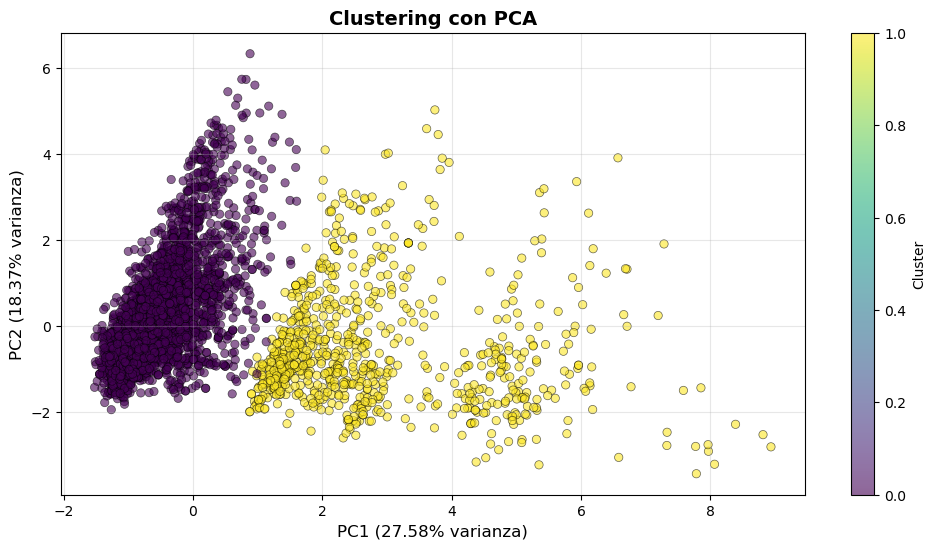

In [27]:
import matplotlib.pyplot as plt

# create a figure with two subplots so axes[0] indexing is valid
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

scatter1 = axes.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
axes.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
axes.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)
axes.set_title('Clustering con PCA', fontsize=14, fontweight='bold')
axes.grid(alpha=0.3)

# optional colorbar
plt.colorbar(scatter1, ax=axes, label='Cluster')